**Jack Dai**

Spring 2026

CS 251 / 252: Data Analysis and Visualization


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 14})

np.set_printoptions(suppress=True, precision=5)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

# Project 4 | Principal component analysis

Principal component analysis (PCA) is a technique to reduce the dimensionality of a dataset while losing the least amount of information about the data variables. Before implementing PCA and exploring its use with different datasets, you will explore what happens when you manually reduce the dimensionality of a mystery dataset from 3D to 2D.


In [2]:
from data_transformations import normalize, center, rotation_matrix_3d
from scatter3d import scatter3dplot

## Task 1: Dimensionality reduction by hand

### 1a. Load and visualize mystery dataset

Load in the mystery dataset (`mystery.csv`) as a pandas DataFrame below. Print out the header and the first five rows of data. You should see:

```
	       x	        y	        z	   color
0	6.183216	86.707892	90.551566	4.810163
1	0.969658	16.972285	137.976605	9.442446
2	0.727076	57.112193	139.795502	9.384942
3	8.433828	30.348513	113.600202	5.973703
4	8.188306	133.978413	120.671505	6.051754
```

**Note:** The `mystery.csv` does not have a types row. Going forward, csv files we work with won't have the types row.


In [3]:
# YOUR CODE HERE
df = pd.read_csv('data/mystery.csv')
print(df.head())

Select the x, y, and z variables from the pandas DataFrame and [convert it to a numpy ndarray](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html).


In [4]:
# YOUR CODE HERE
print(df[['x']], df[['y']], df[['z']])
ndarray = df[['x', 'y', 'z']].to_numpy()

              x
0      6.183216
1      0.969658
2      0.727076
3      8.433828
4      8.188306
...         ...
1995   1.187145
1996   4.564677
1997  11.426294
1998   7.980239
1999   2.438928

[2000 rows x 1 columns]                y
0      86.707892
1      16.972285
2      57.112193
3      30.348513
4     133.978413
...          ...
1995   63.098722
1996   24.097017
1997   97.833703
1998   45.213620
1999   44.630749

[2000 rows x 1 columns]                z
0      90.551566
1     137.976605
2     139.795502
3     113.600202
4     120.671505
...          ...
1995  148.225139
1996  219.453507
1997  155.498854
1998  187.933521
1999   64.432056

[2000 rows x 1 columns]


Use the provided `scatter3dplot` function in `scatter3d.py` to make a 3D scatter plot of the `x`, `y`, and `z` numeric variables. Set the color keyword argument to the `color` variable value from the pandas DataFrame (`len=2000`).

Set the plot bounds (`lims` keyword argument) so that the **entire** dataset appears within the 3D scatter plot. In the provided `scatter3dplot` function, the plot limits that you pass in apply to **all** x, y, and z axes. It may be helpful to print out the min and max of each variable and make sure the bounds that you select encompass all the samples.


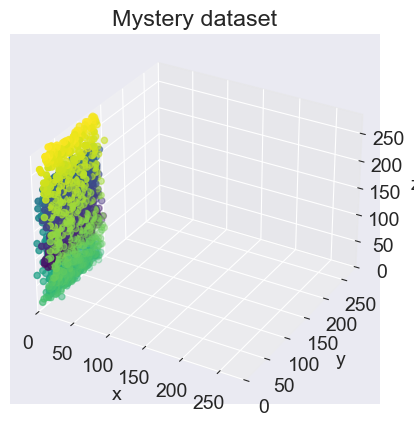

()
()


In [ ]:
# YOUR CODE HERE
color = df['color'].to_numpy()
lims = (ndarray.min(), ndarray.max())
scatter3dplot(
    data_xyz = ndarray, 
    color = color, 
    headers = ['x', 'y', 'z'], 
    lims = lims,
    )

# print(color.shape)
# print(np.min(ndarray))
# print(np.max(ndarray))

### 1b. Preprocess mystery dataset (1/2): Normalize

Implement the `normalize` function in `data_transformations.py` then perform min-max normalization on the `x`, `y`, and `z` values in the mystery dataset.

Use `scatter3dplot` to make a 3D scatterplot of the normalized dataset. Set the color as before, but update the plot limits appropriately based on the new normalized data range.

<!-- In **two lines of code** below, print out the mins and maxes of **each variable** and verify that the data variables are normalized as expected. As above, you should print two length-3 ndarrays — the min and max of each variable (x, y, z) -->


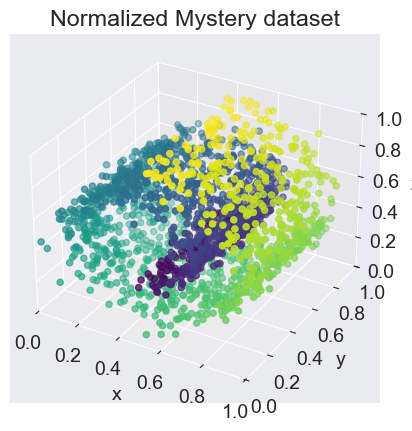

[0. 0. 0.]
[1. 1. 1.]


In [6]:
# YOUR CODE HERE
normalized_ndarray = normalize(ndarray)

normalized_lims = (0, 1)
scatter3dplot(
    data_xyz=normalized_ndarray,
    color=color,
    headers=['x', 'y', 'z'],
    title='Normalized Mystery dataset',
    lims=normalized_lims,
)

print(normalized_ndarray.min(axis=0))
print(normalized_ndarray.max(axis=0))

### 1c. Questions

**Question 1:** What are the min and max values of each variable in the normalized dataset?


**Answer 1:**


Each variable is min-max normalized, so x, y, and z all have a minimum of 0 and a maximum of 1.


**Question 2:** Describe the shape and structure of the normalized mystery dataset. **Why** was the appearance of the dataset not obvious when plotting the raw un-normalized dataset?


**Answer 2:**


After normalization, the dataset forms a clear rolled sheet structure in 3D, with x, y, and z on ranging from 0 to 1.

In the un-normalized plot, that shape was not obvious because the variables had very different numeric ranges, so the axis with larger values dominated the visualization and compressed the structure along other directions.


In [7]:
# verifying min-max
print(normalized_ndarray.min(axis=0))
print(normalized_ndarray.max(axis=0))

[0. 0. 0.]
[1. 1. 1.]


### 1d. Preprocess mystery dataset (2/2): Center

Implement the `center` function in `data_transformations.py` then center the `x`, `y`, and `z` values in the **normalized** mystery dataset. Then use `scatter3dplot` to make a 3D scatterplot of the normalized and centered dataset. Set the color as before.

Update the plot limits appropriately based on the new expected data range so that all data samples appear in the plot, but minimize "filler space" around the dataset in the plot (_i.e. we want to view the full dataset close-up in detail_).


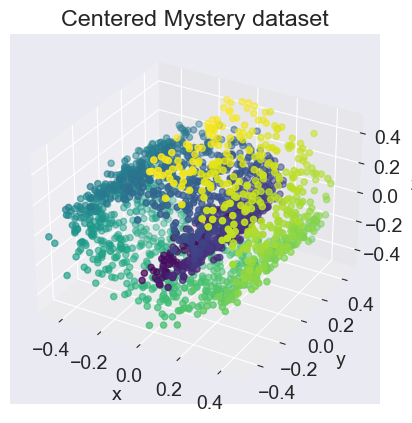

In [8]:
# YOUR CODE HERE
xyz_centered = center(normalized_ndarray)

max_abs = np.abs(xyz_centered).max()
lims_centered = (-max_abs, max_abs)
scatter3dplot(
    data_xyz=xyz_centered,
    color = color,
    headers=['x', 'y', 'z'],
    title='Centered Mystery dataset',
    lims=lims_centered,
)

### 1e. Questions

**Question 3:** Verify below that the normalized mystery dataset is now also centered. **Note:** It is totally fine if you have some `-0.` values.


**Answer 3:**


In [9]:
means = xyz_centered.mean(axis=0)
print('Means of centered variables [x, y, z]:', means)
print('Centered check (all close to 0):', np.allclose(means, 0.0, atol=1e-12))

Means of centered variables [x, y, z]: [0. 0. 0.]
Centered check (all close to 0): True


Yes, the normalized mystery dataset is now centered. The printed means for x, y, and z are all approximately 0 (up to floating-point rounding, including possible `-0.`), which confirms centering was applied correctly.


**Question 4:** What are the min, max, and range of values of each variable? **Why** do these values make sense?


**Answer 4:**


In [17]:
mins = xyz_centered.min(axis=0)
maxs = xyz_centered.max(axis=0)
ranges = maxs - mins

print('Mins [x, y, z]:', mins)
print('Maxs [x, y, z]:', maxs)
print('Ranges [x, y, z]:', ranges)


Mins [x, y, z]: [-0.50103 -0.49286 -0.47661]
Maxs [x, y, z]: [0.49897 0.50714 0.52339]
Ranges [x, y, z]: [1. 1. 1.]


These values make sense because centering subtracts each variable's mean (so values shift around 0), and centering does not change the spread, so each variable keeps the same range as before centering (range 1 after min-max normalization).


### 1f. Projecting mystery dataset from 3D to 2D (1/2)

In the cell below, create a 2D scatter plot showing just the `x` and `y` variables in the normalized and centered mystery dataset.


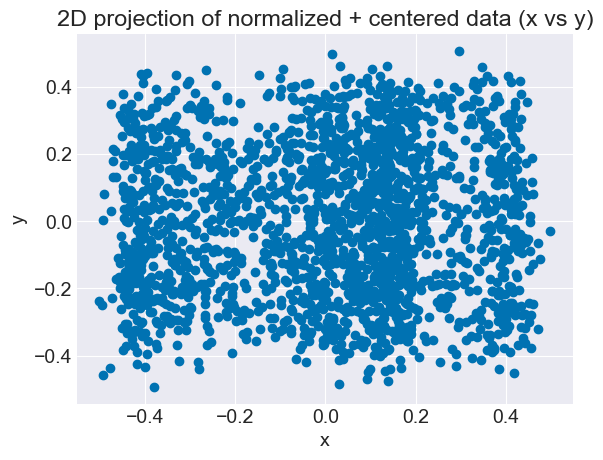

In [11]:
# YOUR CODE HERE
plt.figure()
plt.scatter(xyz_centered[:, 0], xyz_centered[:, 1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D projection of normalized + centered data (x vs y)')
plt.show()

### 1g. Questions

**Question 5:** Based on your 2D scatter plot, does the projection that you performed in Task 1f look like a "helpful" lower dimensional representation of the dataset? **Why?**


**Answer 5:**


No, this projection is not very helpful.

Projecting the 3D normalized-centered data directly onto the x-y plane causes many points that are separated in 3D (especially along z) to overlap in 2D. That mixes different parts of the rolled structure together, so the key geometric pattern is not clearly preserved in this view.


### 1h. Implement `rotation_matrix_3d`

In `data_transformations.py` implement `rotation_matrix_3d` then test it below.


#### Test `rotation_matrix_3d`


In [12]:
# Test rotate about x axis
print('Your 3D Rotation matrix about x axis by +30° is:')
print(rotation_matrix_3d(30, axis='x'))
print('and should be:')
print('''[[ 1.       0.       0.     ]
 [ 0.       0.86603 -0.5    ]
 [ 0.       0.5      0.86603]]''')

# Test rotate about y axis
print('Your 3D Rotation matrix about y axis by -15° is:')
print(rotation_matrix_3d(-15, axis='y'))
print('and should be:')
print('''[[ 0.96593  0.      -0.25882]
 [ 0.       1.       0.     ]
 [ 0.25882  0.       0.96593]]''')

# Test rotate about z axis
print('Your 3D Rotation matrix about z axis by 45° is:')
print(rotation_matrix_3d(45, axis='z'))
print('and should be:')
print('''[[ 0.70711 -0.70711  0.     ]
 [ 0.70711  0.70711  0.     ]
 [ 0.       0.       1.     ]]''')

Your 3D Rotation matrix about x axis by +30° is:
[[ 1.       0.       0.     ]
 [ 0.       0.86603 -0.5    ]
 [ 0.       0.5      0.86603]]
and should be:
[[ 1.       0.       0.     ]
 [ 0.       0.86603 -0.5    ]
 [ 0.       0.5      0.86603]]
Your 3D Rotation matrix about y axis by -15° is:
[[ 0.96593  0.      -0.25882]
 [ 0.       1.       0.     ]
 [ 0.25882  0.       0.96593]]
and should be:
[[ 0.96593  0.      -0.25882]
 [ 0.       1.       0.     ]
 [ 0.25882  0.       0.96593]]
Your 3D Rotation matrix about z axis by 45° is:
[[ 0.70711 -0.70711  0.     ]
 [ 0.70711  0.70711  0.     ]
 [ 0.       0.       1.     ]]
and should be:
[[ 0.70711 -0.70711  0.     ]
 [ 0.70711  0.70711  0.     ]
 [ 0.       0.       1.     ]]


### 1i. Projecting mystery dataset from 3D to 2D (2/2)

Reduce the dimensionality of the **normalized and centered** mystery dataset from 3D -> 2D while doing a better job at preserving the "rolled" shape than in Task 1f. Do this below by projecting the 3D dataset into the (`x`, `y`) plane just like you did in Task 1f (i.e. make a 2D scatter plot of `x` and `y`), but this time rotate the 3D normalized and centered mystery dataset **beforehand**. The amount of 3D rotation and the axis about which it is performed is up to you.

Your goal is to rotate the 3D dataset so that the "rolled" spiral structure (_i.e. the key shape of the dataset_) comes into view of the `x`-`y` plane/axis when you project the dataset down into 2D via your 2D scatter plot.

The cell below should show a 2D scatter plot with the spiral/rolled structure clearly visible.

**Note:** It should be helpful to plot the normalized and centered mystery dataset in 3D with `scatter3dplot` before and after the rotation.


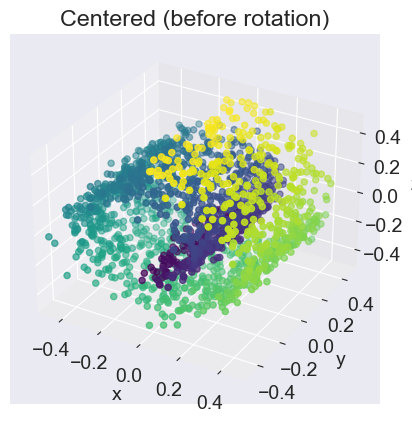

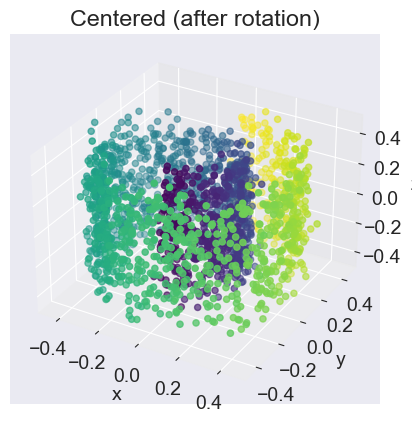

In [13]:
# YOUR CODE HERE
# Rotate centered data.
R = rotation_matrix_3d(-90, axis='x')
xyz_rot = (R @ xyz_centered.T).T

lims_rot = (xyz_rot.min(), xyz_rot.max())
scatter3dplot(xyz_centered, color=color, headers=['x', 'y', 'z'], title='Centered (before rotation)', lims=lims_centered)
scatter3dplot(xyz_rot, color=color, headers=['x', 'y', 'z'], title='Centered (after rotation)', lims=lims_rot)

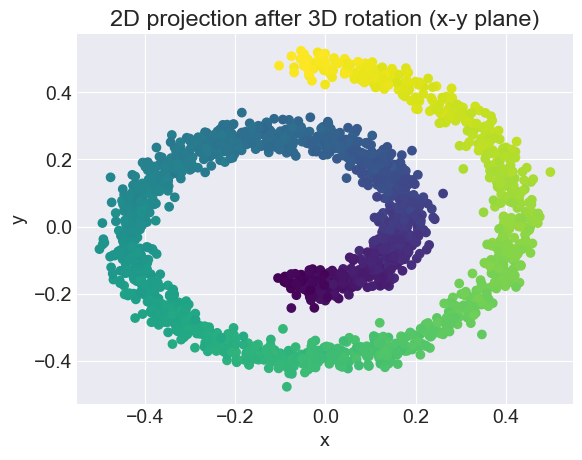

In [14]:
# YOUR CODE HERE
plt.figure()
plt.scatter(xyz_rot[:, 0], xyz_rot[:, 1], c=color, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D projection after 3D rotation (x-y plane)')
plt.show()